# Prostate Slide-seq V2 microarchitecture analysis

This notebook restores the five jointly identified prostate microarchitectures from GEO accession GSE181294 with the STEP `MicroArc` wrapper and evaluates their cell-type organization and ligand-receptor programs. The required checkpoint and center-assignment table are generated from `prostate_slideseq_step.h5ad` by `scripts/prostate_slideseq_v2/build_microarchitecture.py`.

**Data source:** Human prostate Slide-seq V2 data from GEO accession [GSE181294](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE181294).

## Setup

In [ ]:
from pathlib import Path
import pickle

import liana as li
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from step.models.niche import MicroArc

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = Path("../..").resolve()
RESULTS_ROOT = REPO_ROOT / "results" / "slide-seq"


## Restore the five prostate microarchitectures

The saved center assignments retain the five-MA solution used by the manuscript. `MicroArc` reconstructs the corresponding local graphs for downstream visualization.

In [ ]:
with open(RESULTS_ROOT / "prostate_microarchitecture_results.pkl", "rb") as handle:
    results = pickle.load(handle)

metadata = pd.read_csv(
    RESULTS_ROOT / "prostate_microarchitecture_metadata.csv",
    index_col=0,
)
metadata.loc[results["centers"].index, "is_center"] = True
metadata.loc[results["centers"].index, "center_pattern"] = results["clusters"]
adata = sc.read_h5ad(RESULTS_ROOT / "prostate_slideseq_step.h5ad")

n_microarchitectures = len(np.unique(results["clusters"]))
if n_microarchitectures != 5:
    raise ValueError(
        f"Expected five prostate microarchitectures, found {n_microarchitectures}"
    )


In [4]:
niche = MicroArc.restore_from_metadata(
    metadata,
    center_pattern_key="center_pattern",
    label_col="cell1",
    batch_col="sample",
    radius=50.0,
)


Found 3292 low coherence centers


Creating graphs for batch Tumor02: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 523/523 [00:00<00:00, 2045.87it/s]


## Graph-kernel structure

In [6]:
kernel_matrix = niche.compute_kernel_matrix()
kernel_matrix

Computing kernel blocks: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:01<00:00,  1.95s/it, block=(0,0), size=3292x3292]


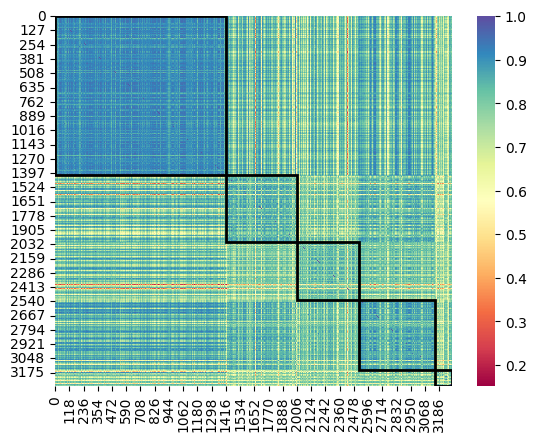

In [9]:
import matplotlib.pyplot as plt

ind = np.argsort(niche.clusters)
sorted_matrix = kernel_matrix[ind][:, ind]

# Create the heatmap
fig, ax = plt.subplots()
sns.heatmap(sorted_matrix, cmap='Spectral')

# Add boxes for each cluster
current_idx = 0
unique_clusters = np.unique(np.sort(niche.clusters))
for cluster in unique_clusters:
    # Count points in this cluster
    cluster_size = np.sum(niche.clusters[ind] == cluster)
    
    # Draw rectangle around the cluster
    ax.add_patch(plt.Rectangle((current_idx, current_idx), 
                              cluster_size, cluster_size,
                              fill=False, edgecolor='black', linewidth=2))
    current_idx += cluster_size

plt.show()

## Average cell-type organization

Each panel summarizes the recurring cell-type graph associated with one microarchitecture.

Found 1414 cells with pattern 0
Found 1414 cells with pattern 0
Found 1414 cells with pattern 0
Found 597 cells with pattern 1
Found 597 cells with pattern 1
Found 597 cells with pattern 1
Found 514 cells with pattern 2
Found 514 cells with pattern 2
Found 514 cells with pattern 2
Found 630 cells with pattern 3
Found 630 cells with pattern 3
Found 630 cells with pattern 3
Found 137 cells with pattern 4
Found 137 cells with pattern 4
Found 137 cells with pattern 4


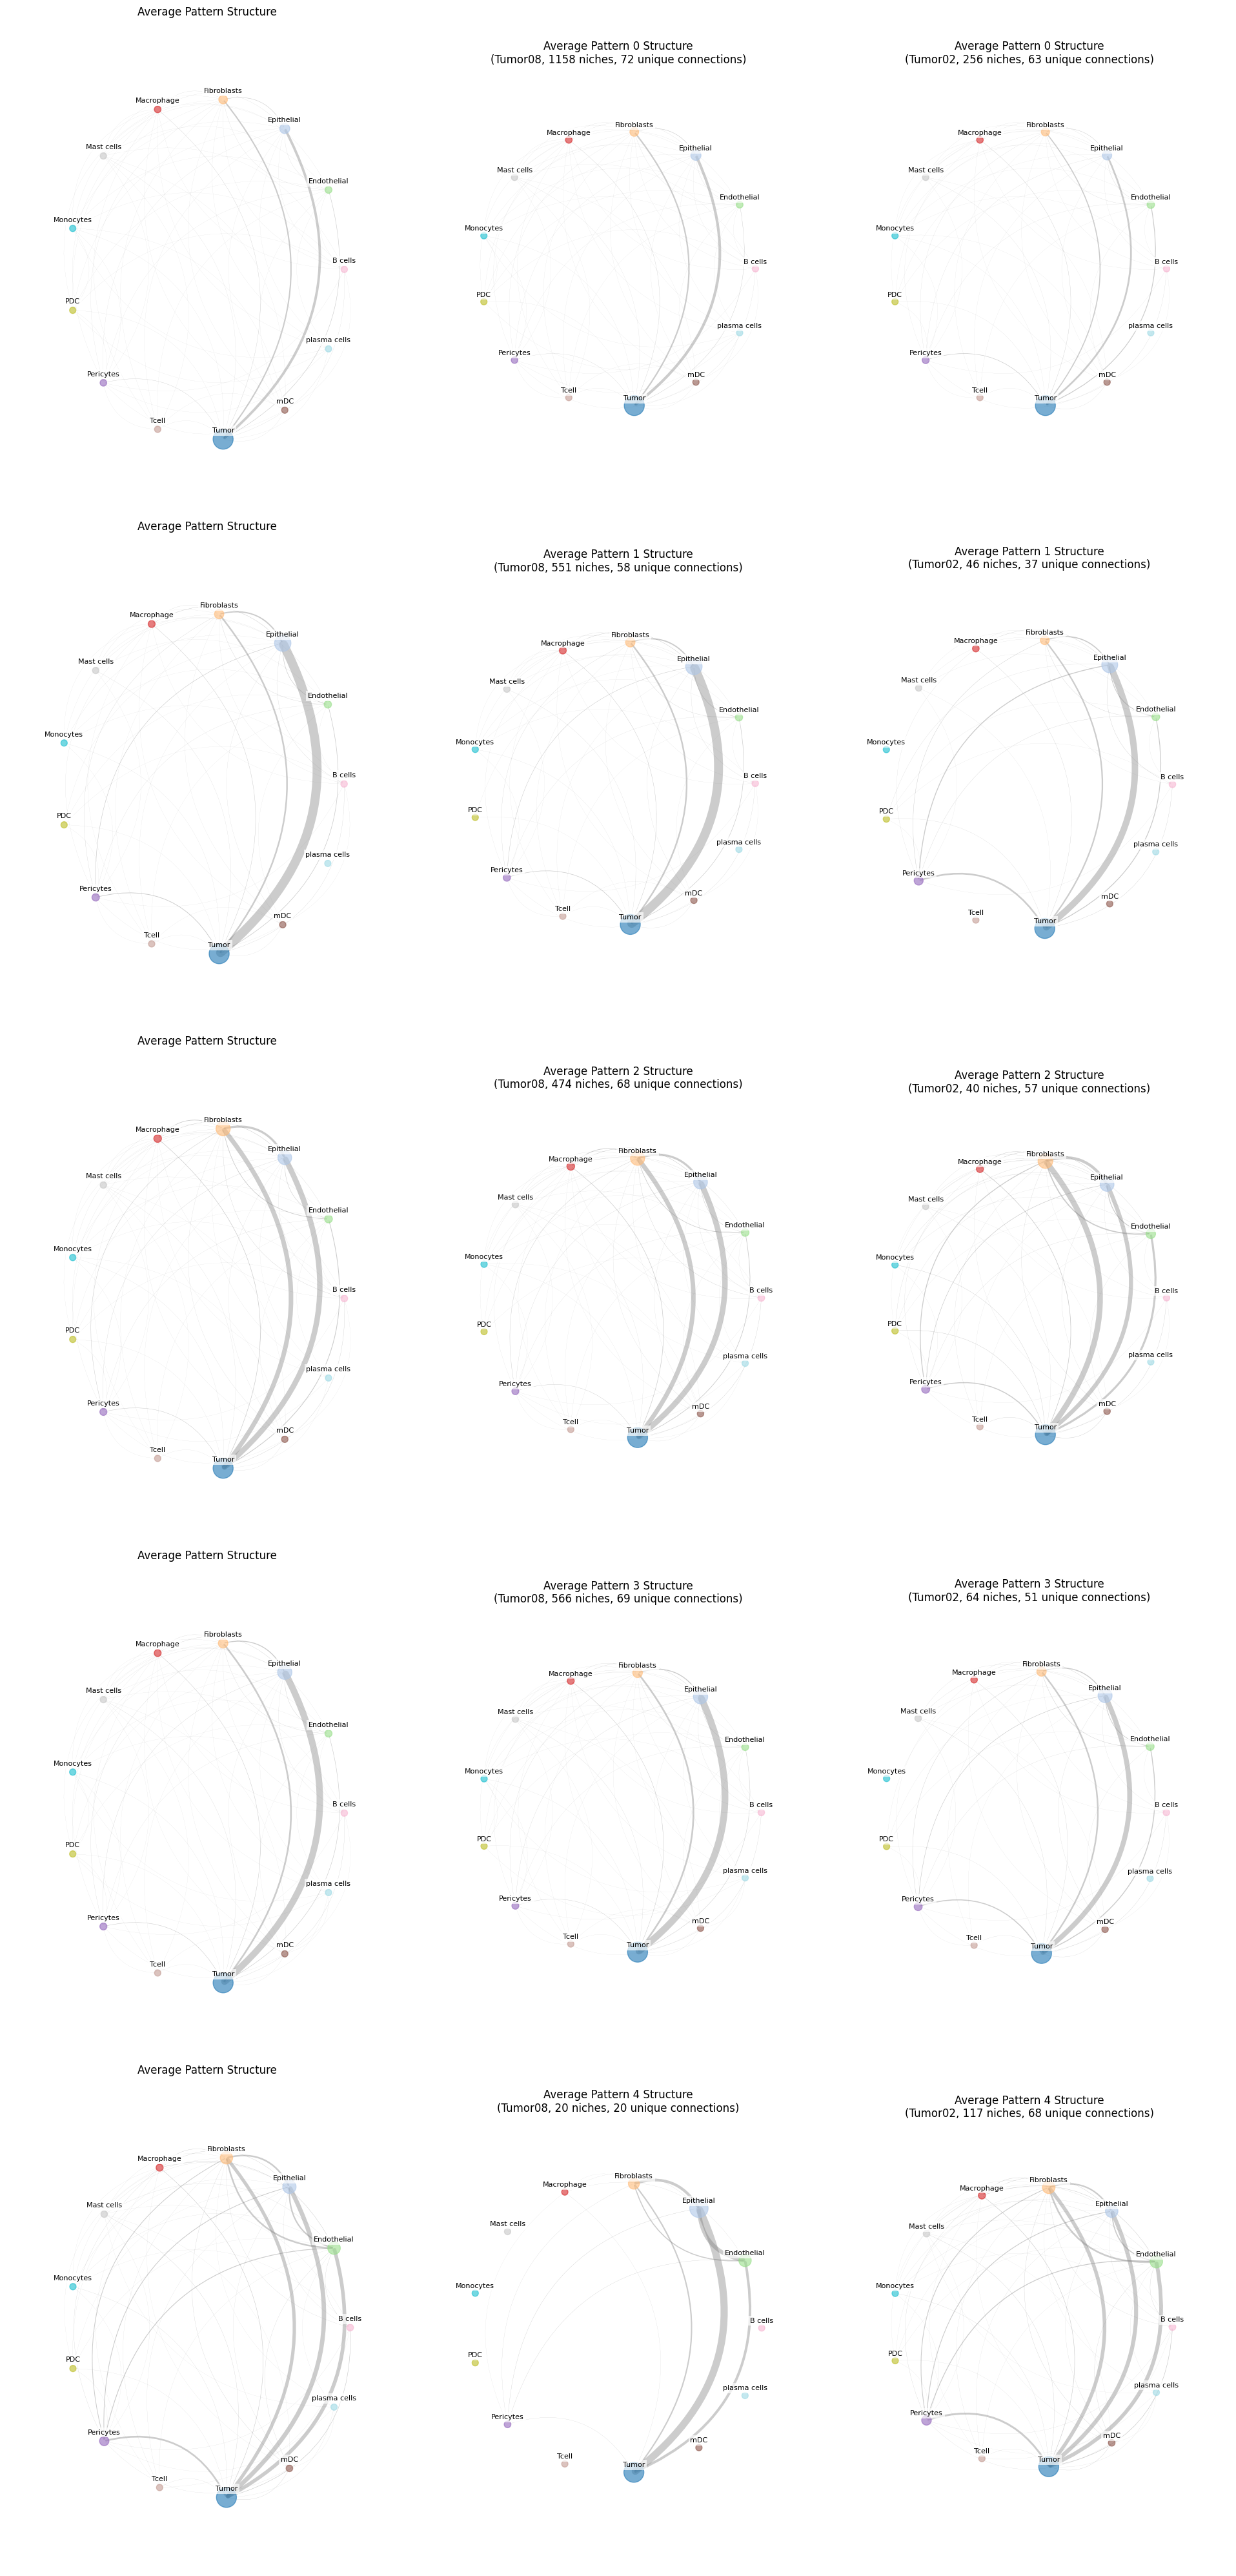

In [8]:
niche.plot_patterns(show_edges=True,
                    figsize_multiplier=(32, 8),
                    # node_size_range=(10, 100),
                    edge_width_range=(0.1, 10),
                    edge_curve=0.4,
                   )

## Ligand-receptor programs across the five microarchitectures

CellPhoneDB is evaluated on the cells represented by the local graphs in each MA.

In [168]:
from liana.method import cellphonedb

def analyze_pattern_programs(adata, results):
    """
    Run CellPhoneDB separately for each microarchitecture
    """
    import pandas as pd
    import numpy as np
    import anndata as ad
    
    niche_graphs = results['niche_graphs']
    clusters = results['clusters']
    n_patterns = len(np.unique(clusters))
    adatas = {}
    def get_neighbors(pattern_indices):
        """Get expression profiles of neighbors of specific cell type from given niches"""
        neighbors = []
        for idx in pattern_indices:
            niche = niche_graphs[idx]
            cell_indices = niche['neighbors'].index
            neighbors.extend(cell_indices)
        return adata[np.unique(neighbors)]
        
    for pattern in range(n_patterns):
        print(f"\nAnalyzing pattern {pattern}")
        degs_pattern = []
        
        pattern_indices = np.where(clusters == pattern)[0]
        other_indices = np.where(clusters != pattern)[0]
        
        pattern_adata = get_neighbors(pattern_indices)
        
        if len(pattern_adata) < 3:
            print(f"Skipping pattern {pattern}: insufficient cells")
            continue
        
        cellphonedb(
            pattern_adata,
            groupby='cell1',
            resource_name='consensus',
            expr_prop=0.1,
            verbose=True, key_added='cpdb_res')
        adatas[f"pattern_{pattern}"] = pattern_adata
        
    return adatas


In [171]:
pattern_adatas = analyze_pattern_programs(adata, results)


Analyzing pattern 0


Generating ligand-receptor stats for 16652 samples and 1378 features



Analyzing pattern 1
Generating ligand-receptor stats for 6801 samples and 1324 features



Analyzing pattern 2
Generating ligand-receptor stats for 5973 samples and 1317 features



Analyzing pattern 3
Generating ligand-receptor stats for 9193 samples and 1353 features



Analyzing pattern 4
Generating ligand-receptor stats for 2486 samples and 1183 features


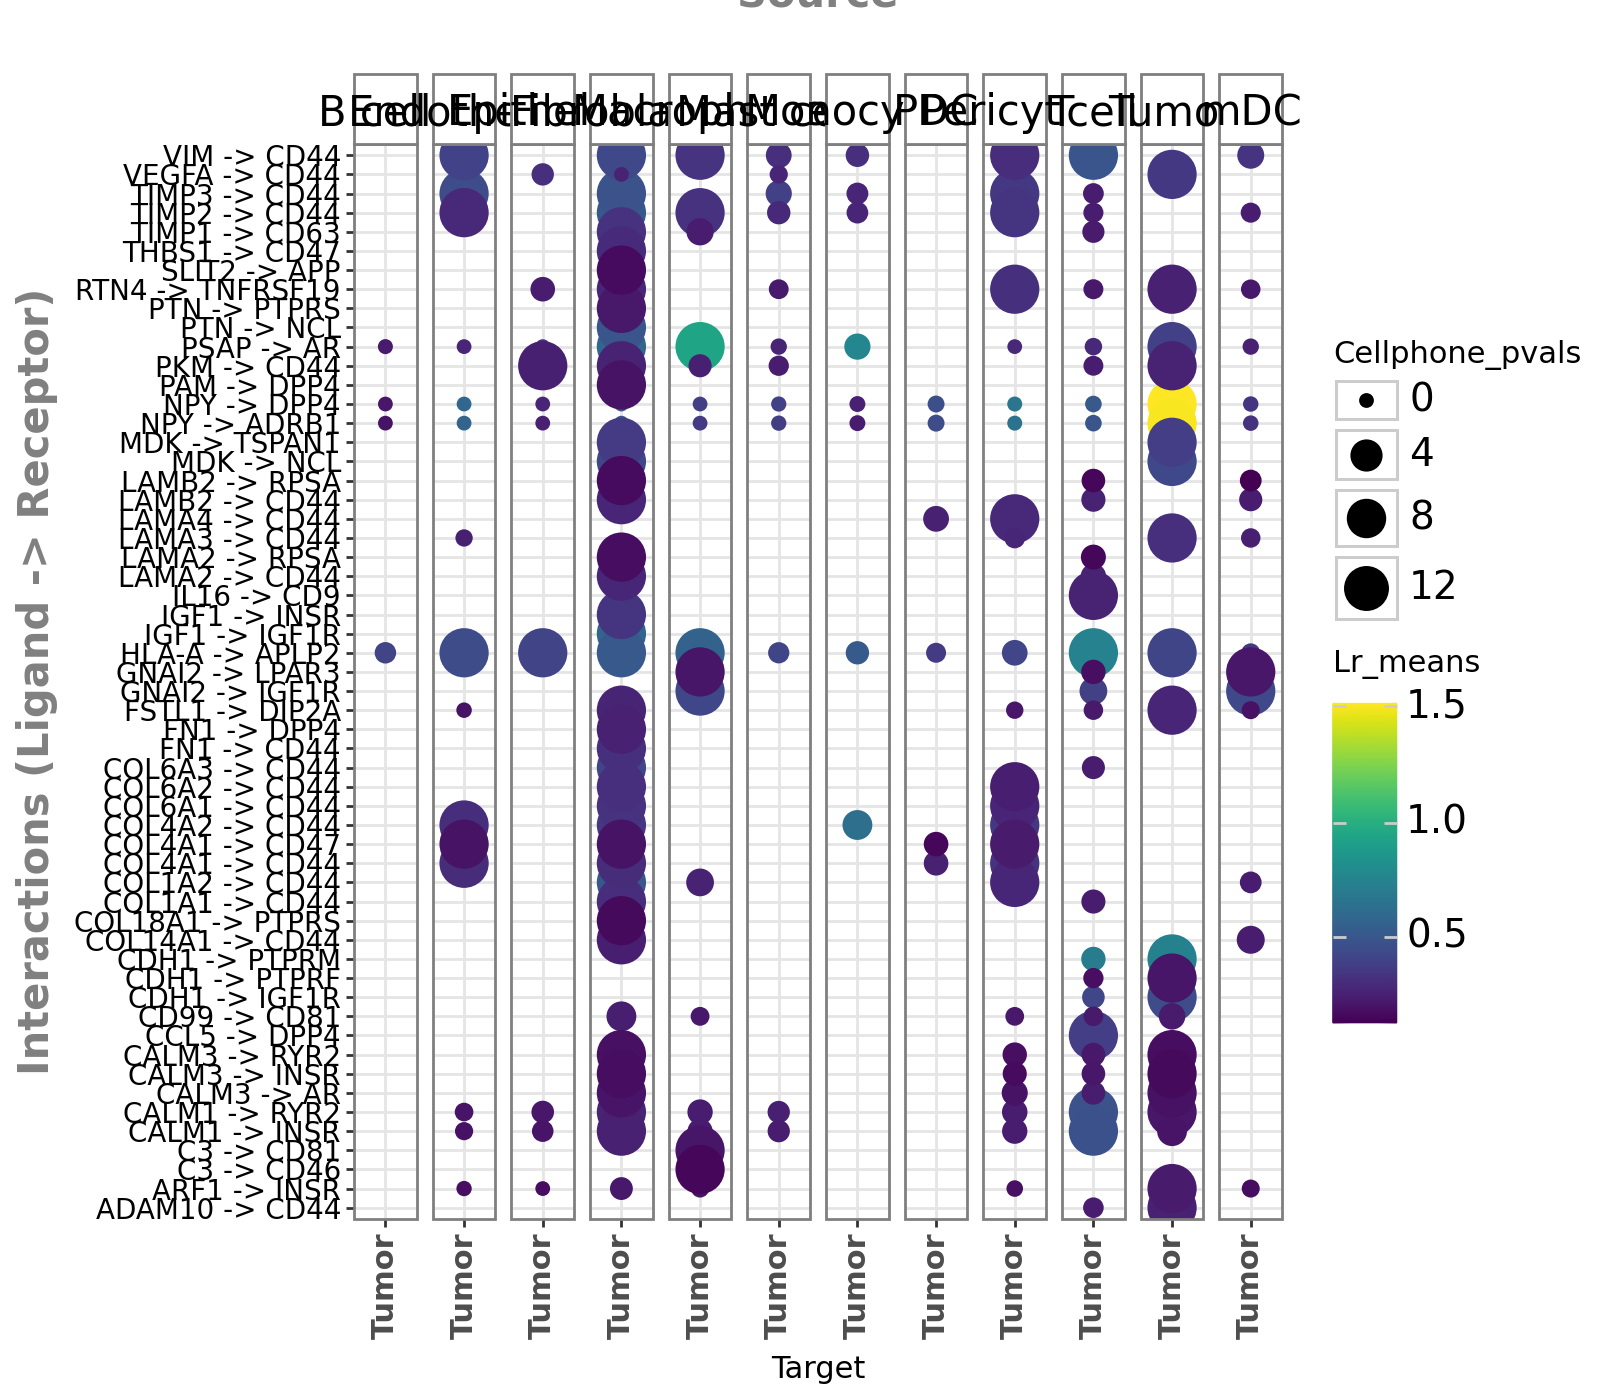

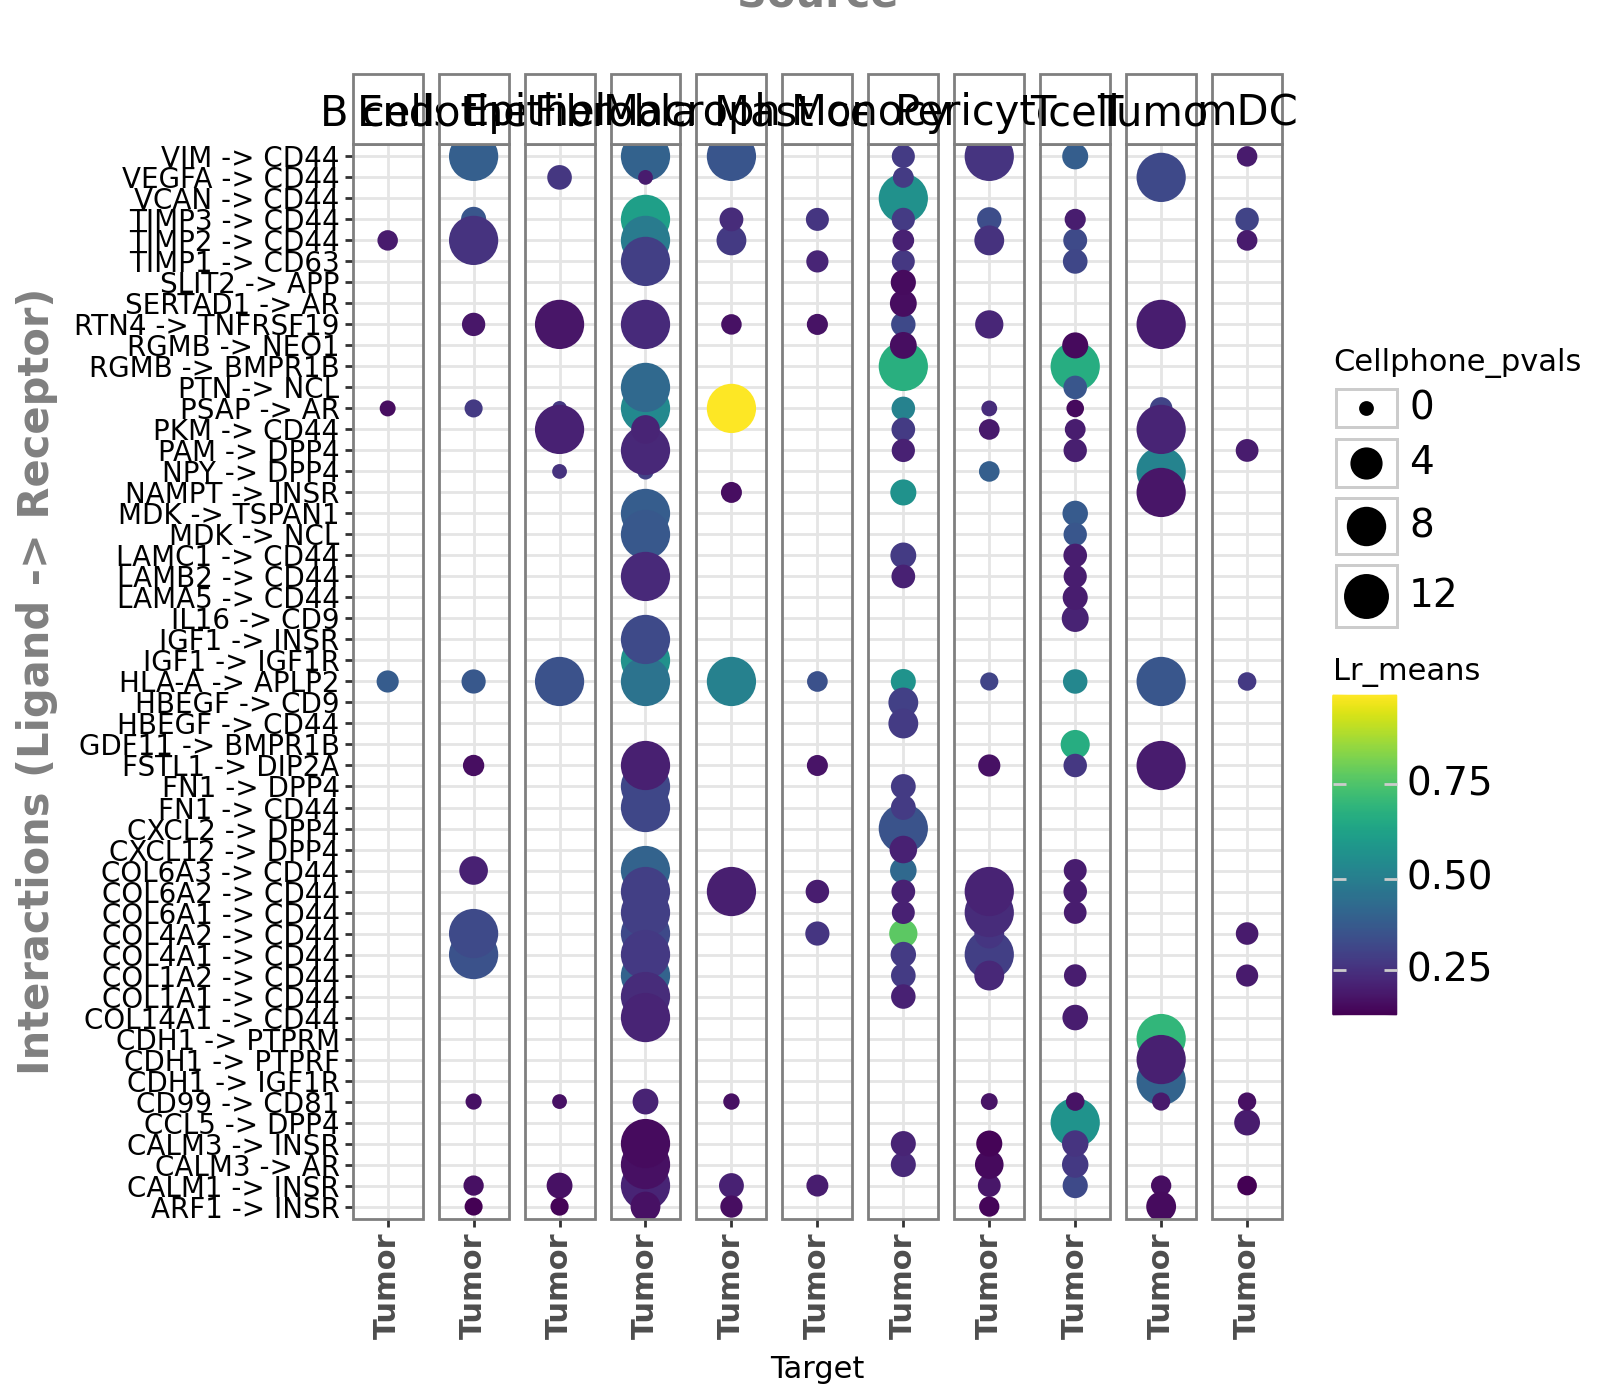

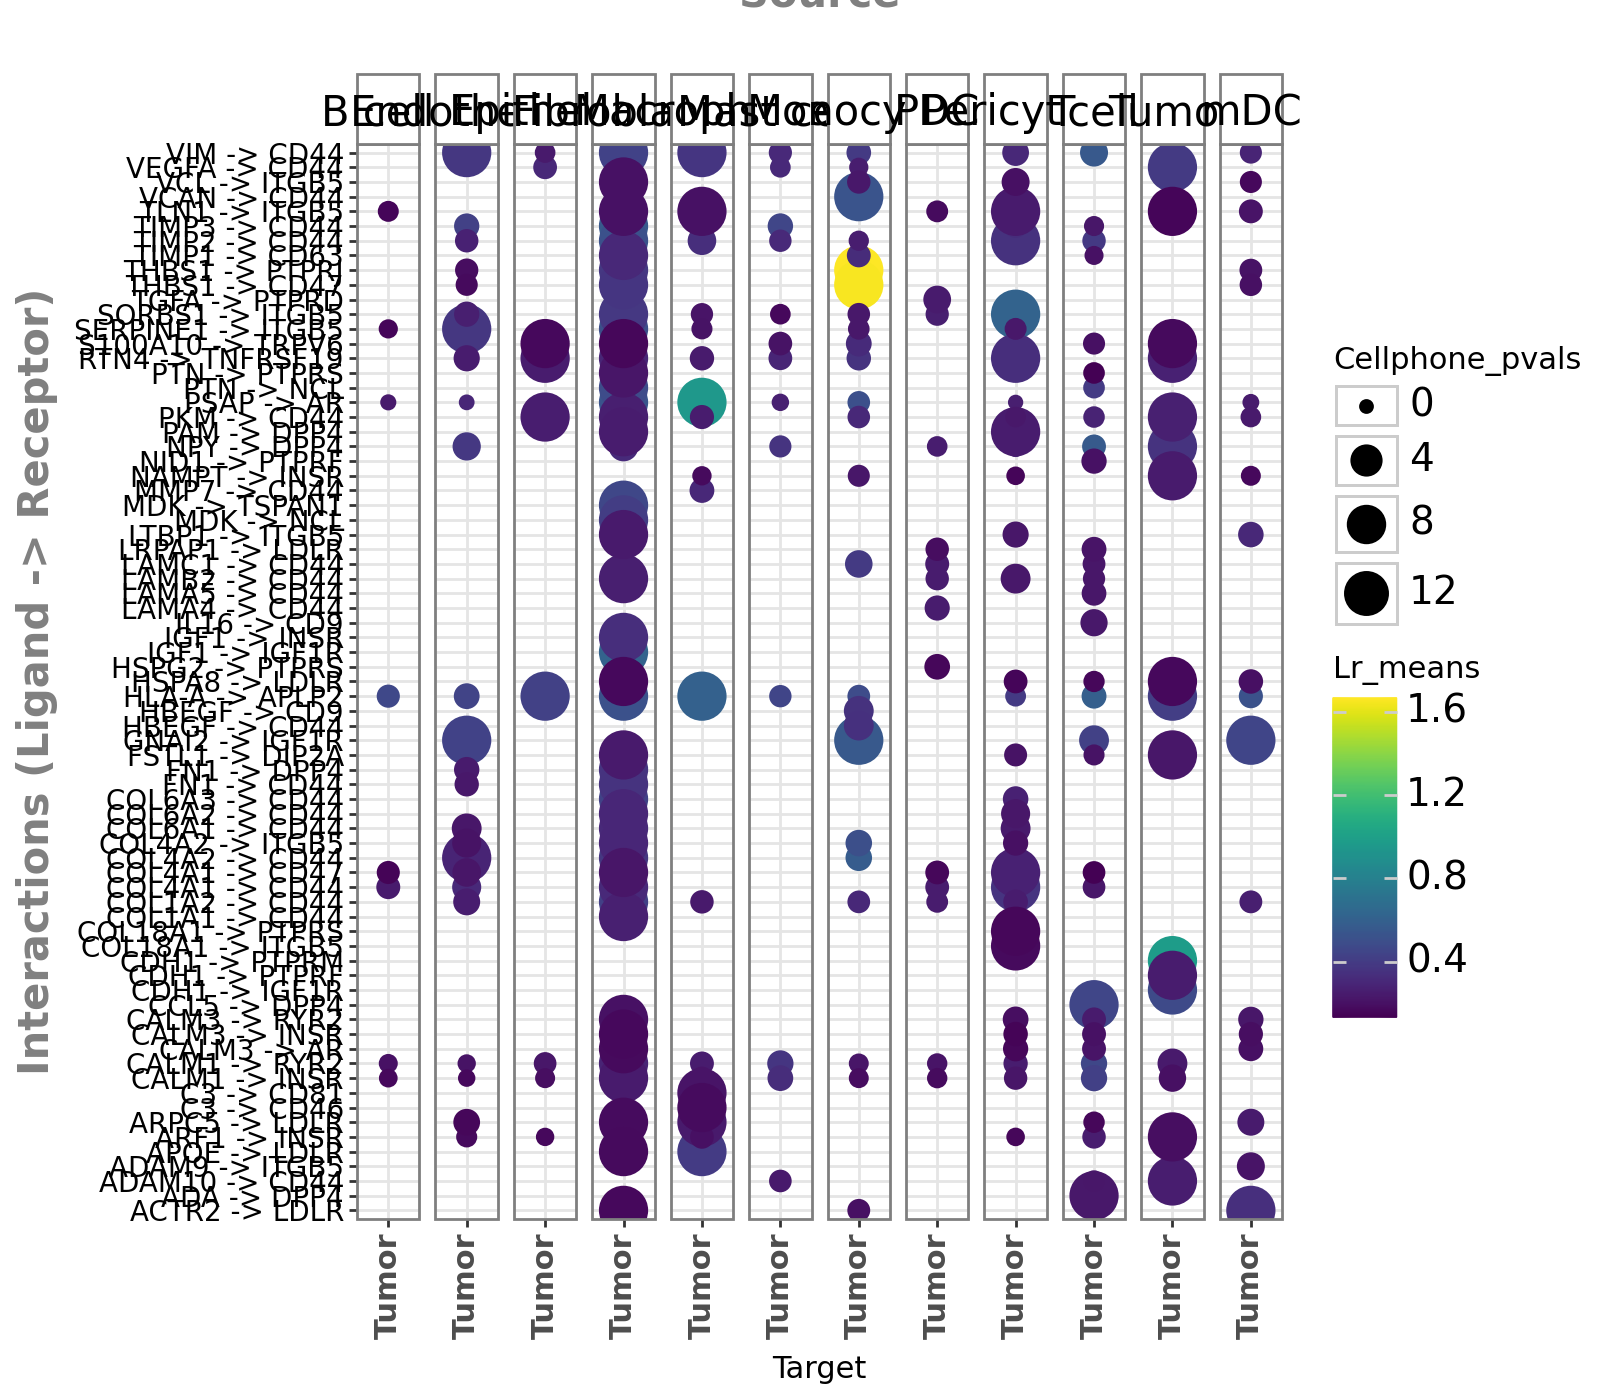

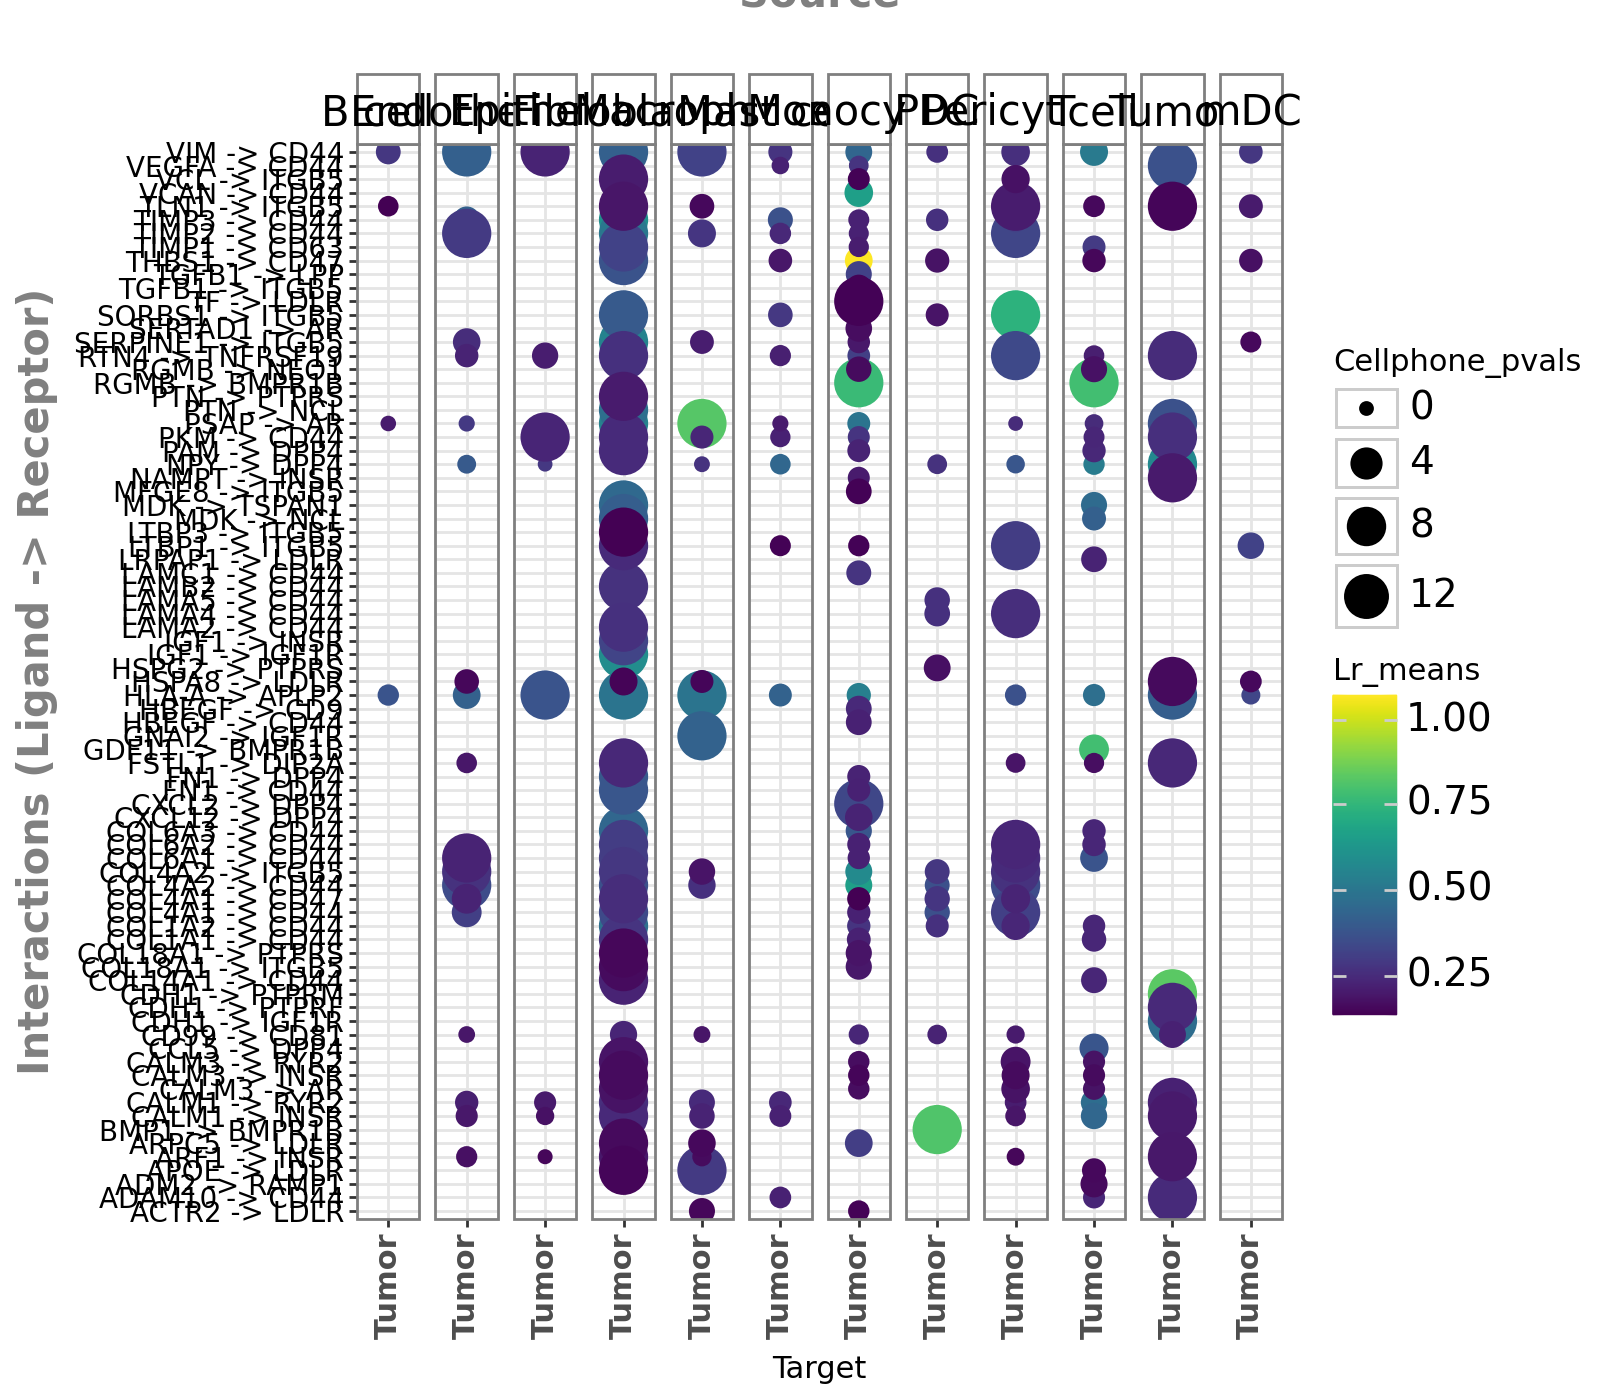

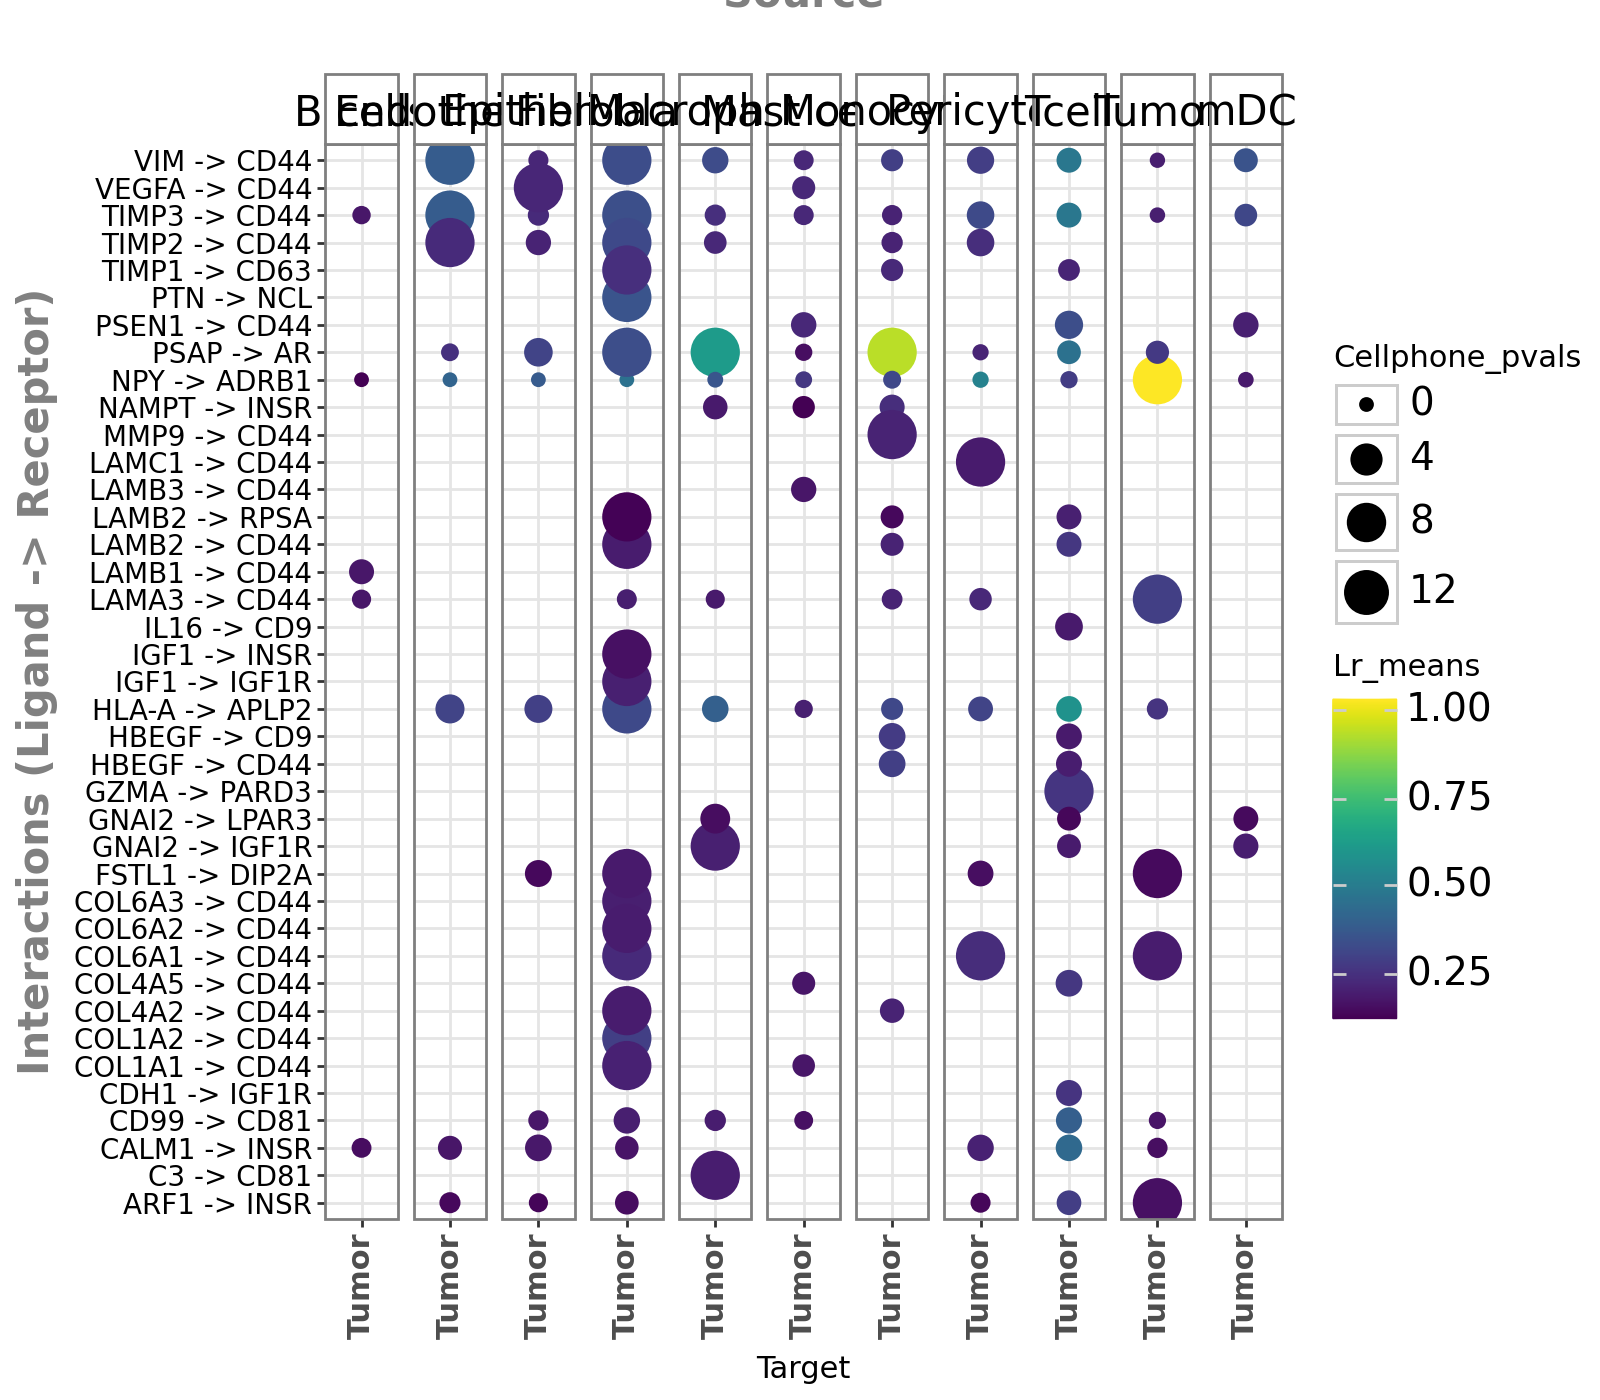

In [183]:
for pattern in pattern_adatas.keys():
    pattern_adata = pattern_adatas[pattern]
    fig = li.pl.dotplot(adata = pattern_adata,
                  colour='lr_means',
                  size='cellphone_pvals',
                  inverse_size=True, # we inverse sign since we want small p-values to have large sizes
                  source_labels=pattern_adata.uns['cpdb_res']['source'].unique(),
                  target_labels=['Tumor'],
                  figure_size=(8, 7),
                  filter_fun=lambda x: x['cellphone_pvals'] <= 0.05,
                  uns_key='cpdb_res' # uns_key to use, default is 'liana_res'
                 )
    fig.show()


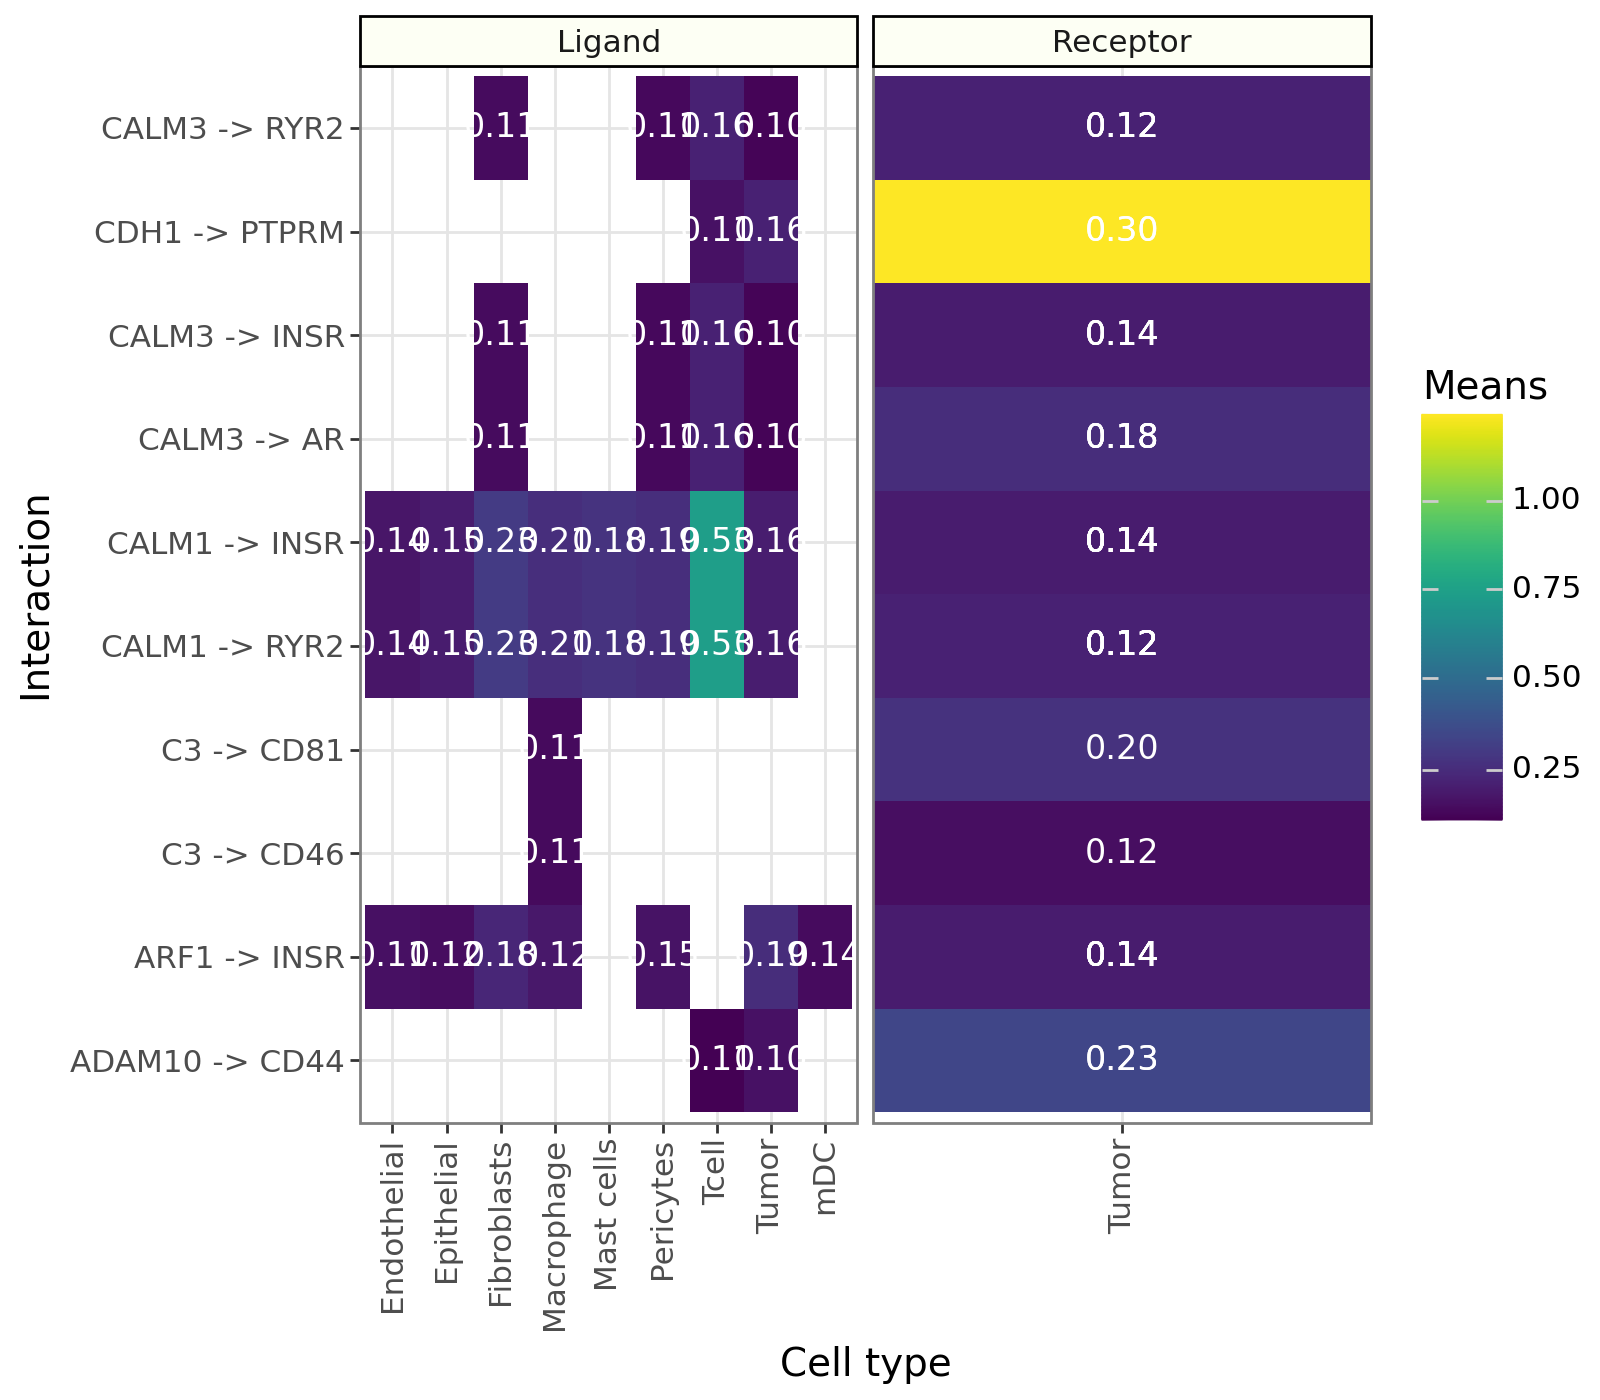

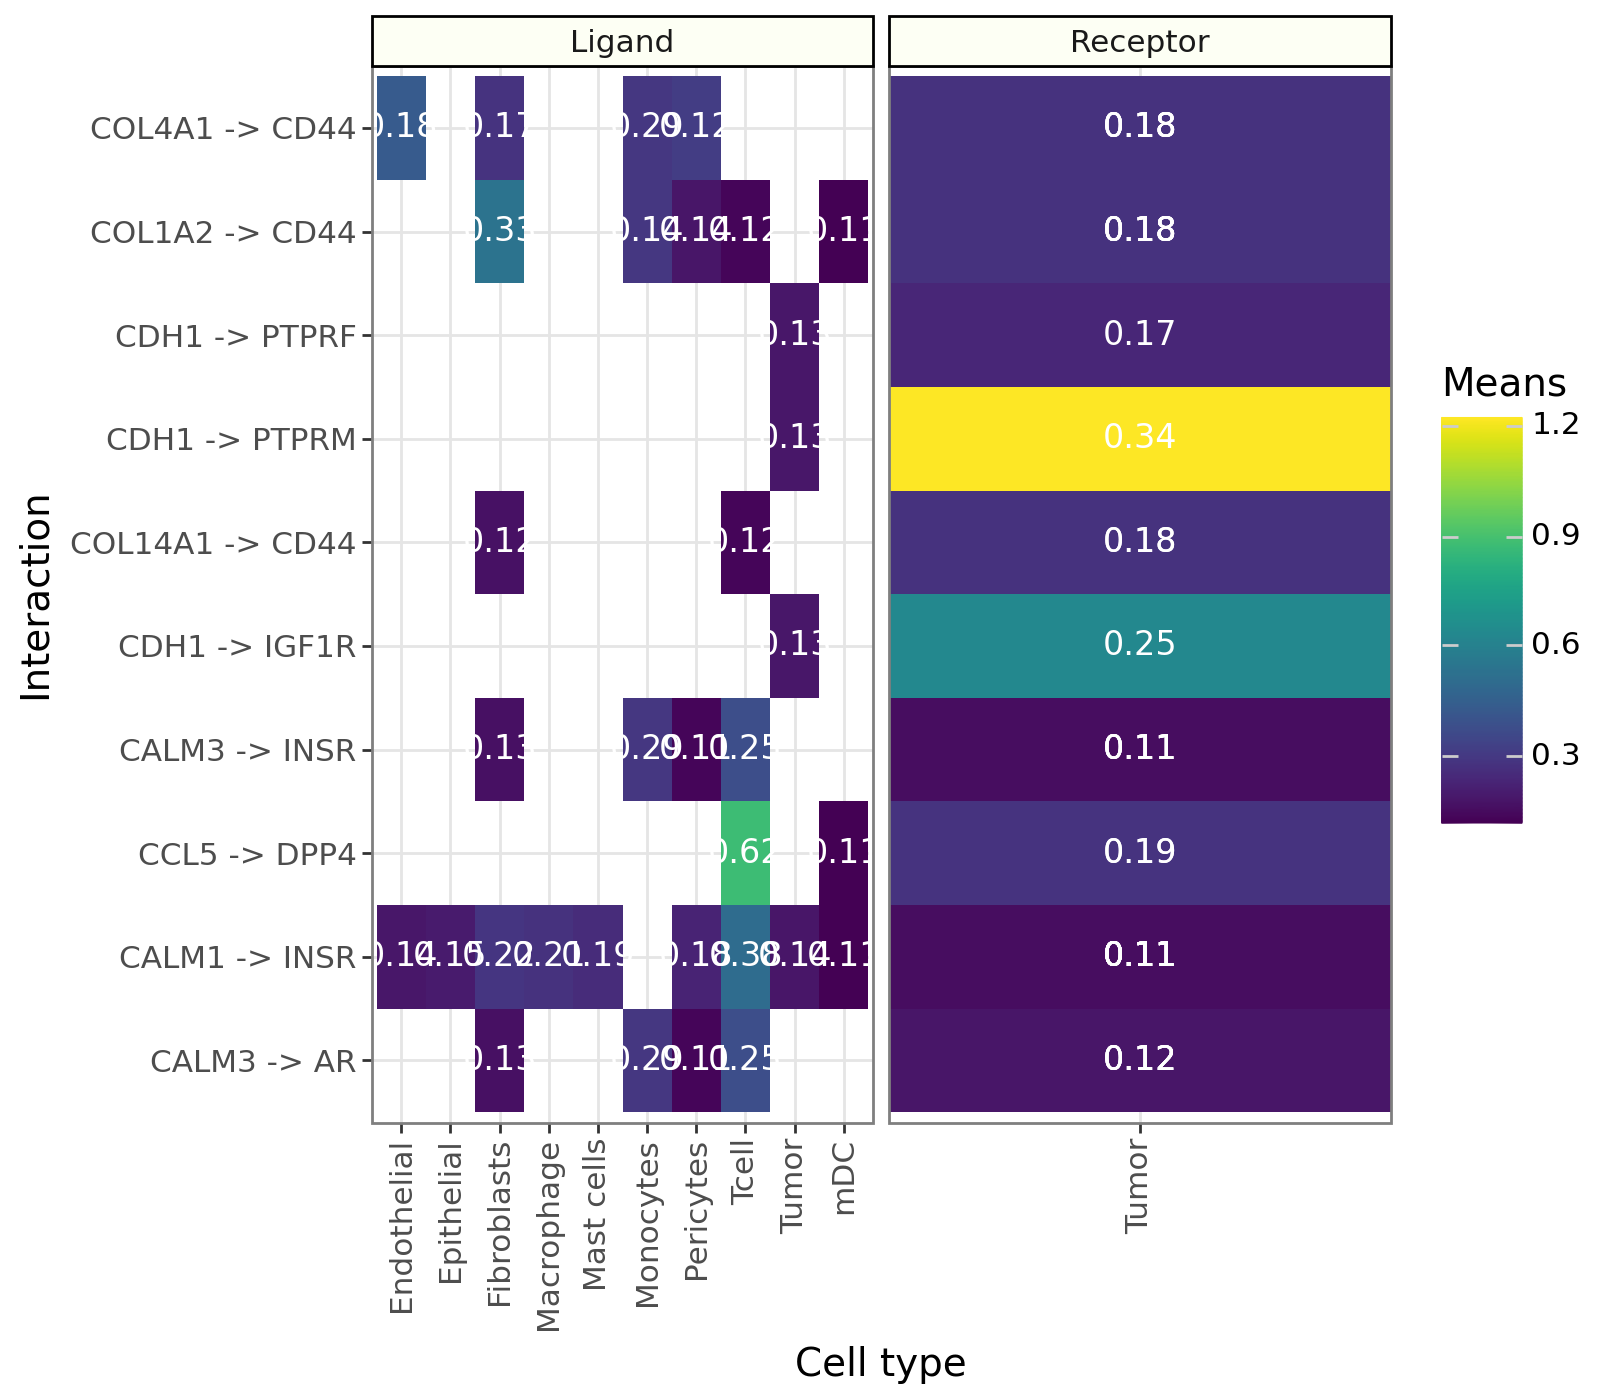

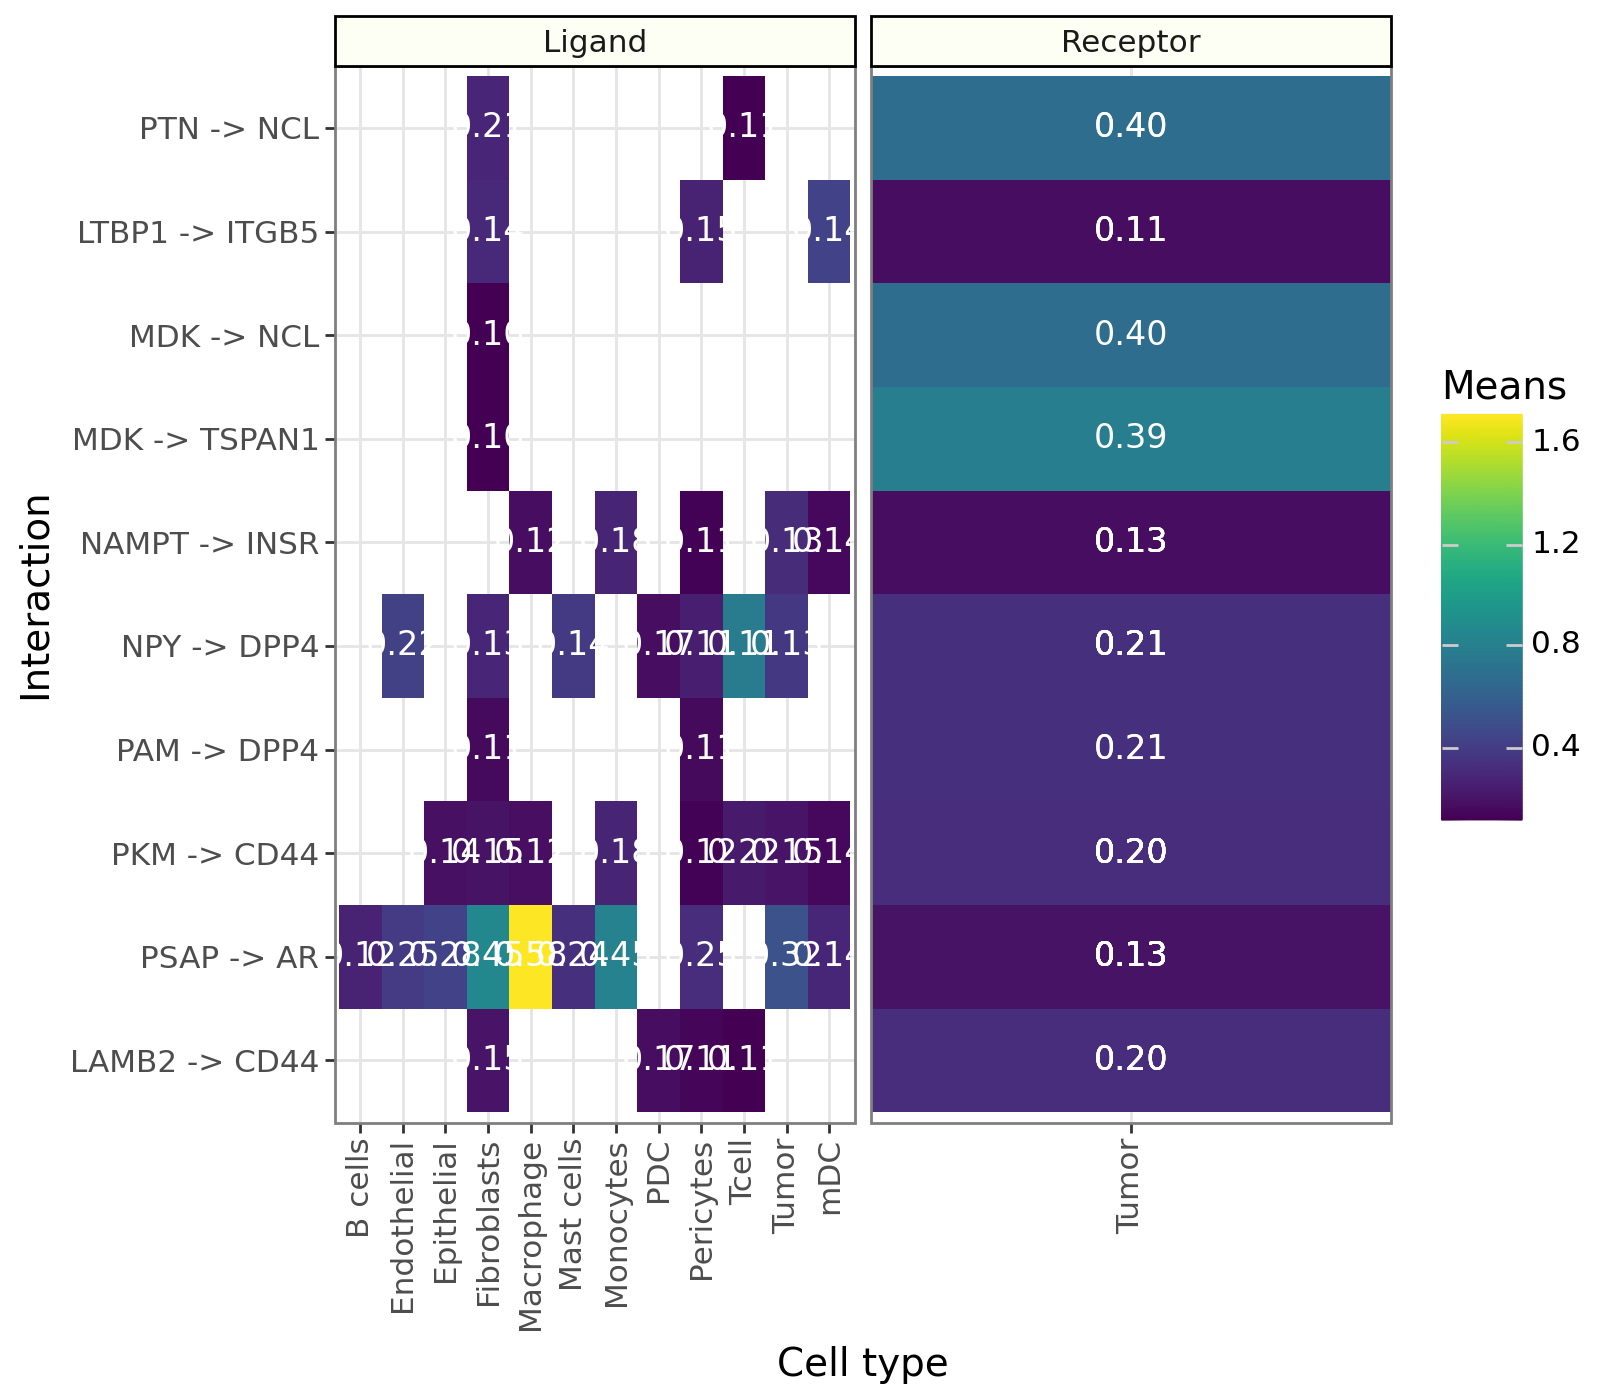

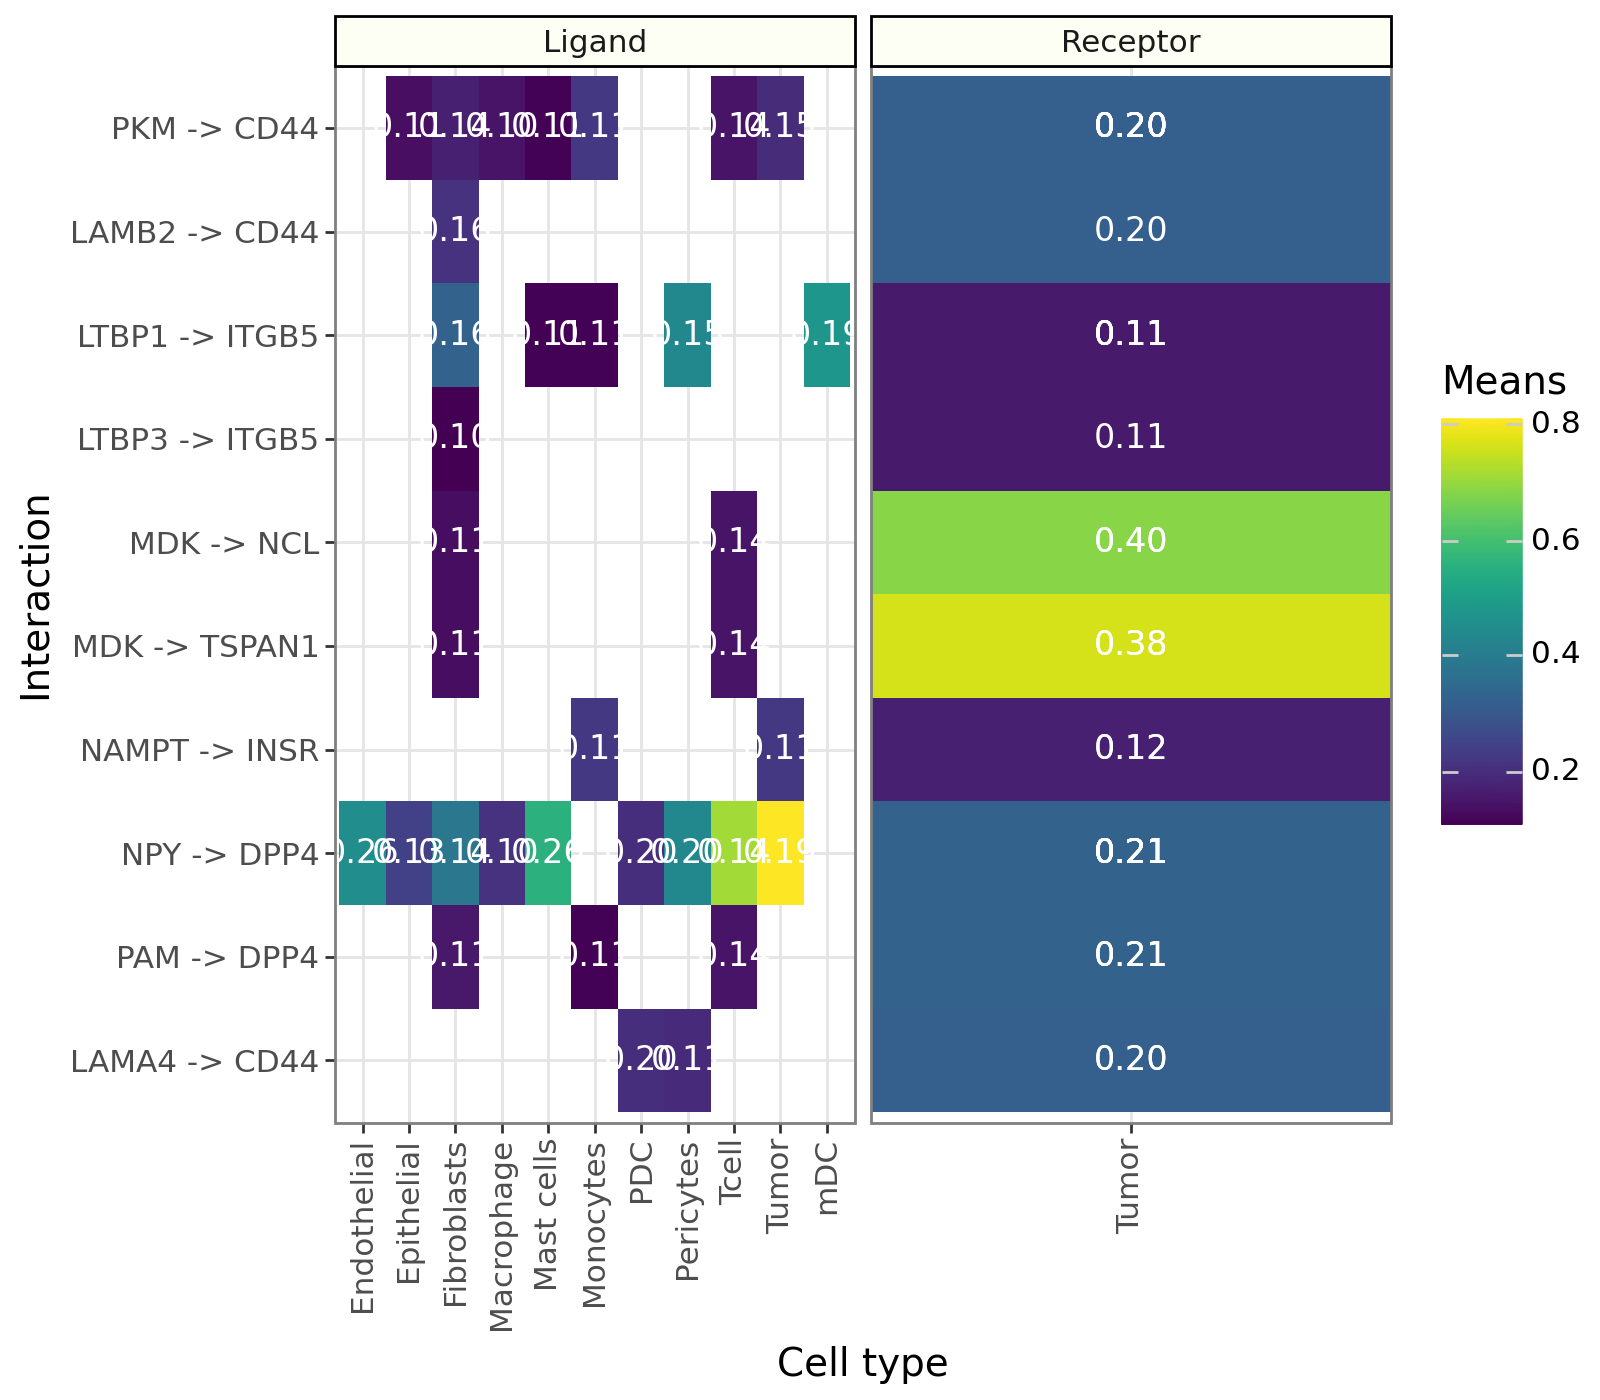

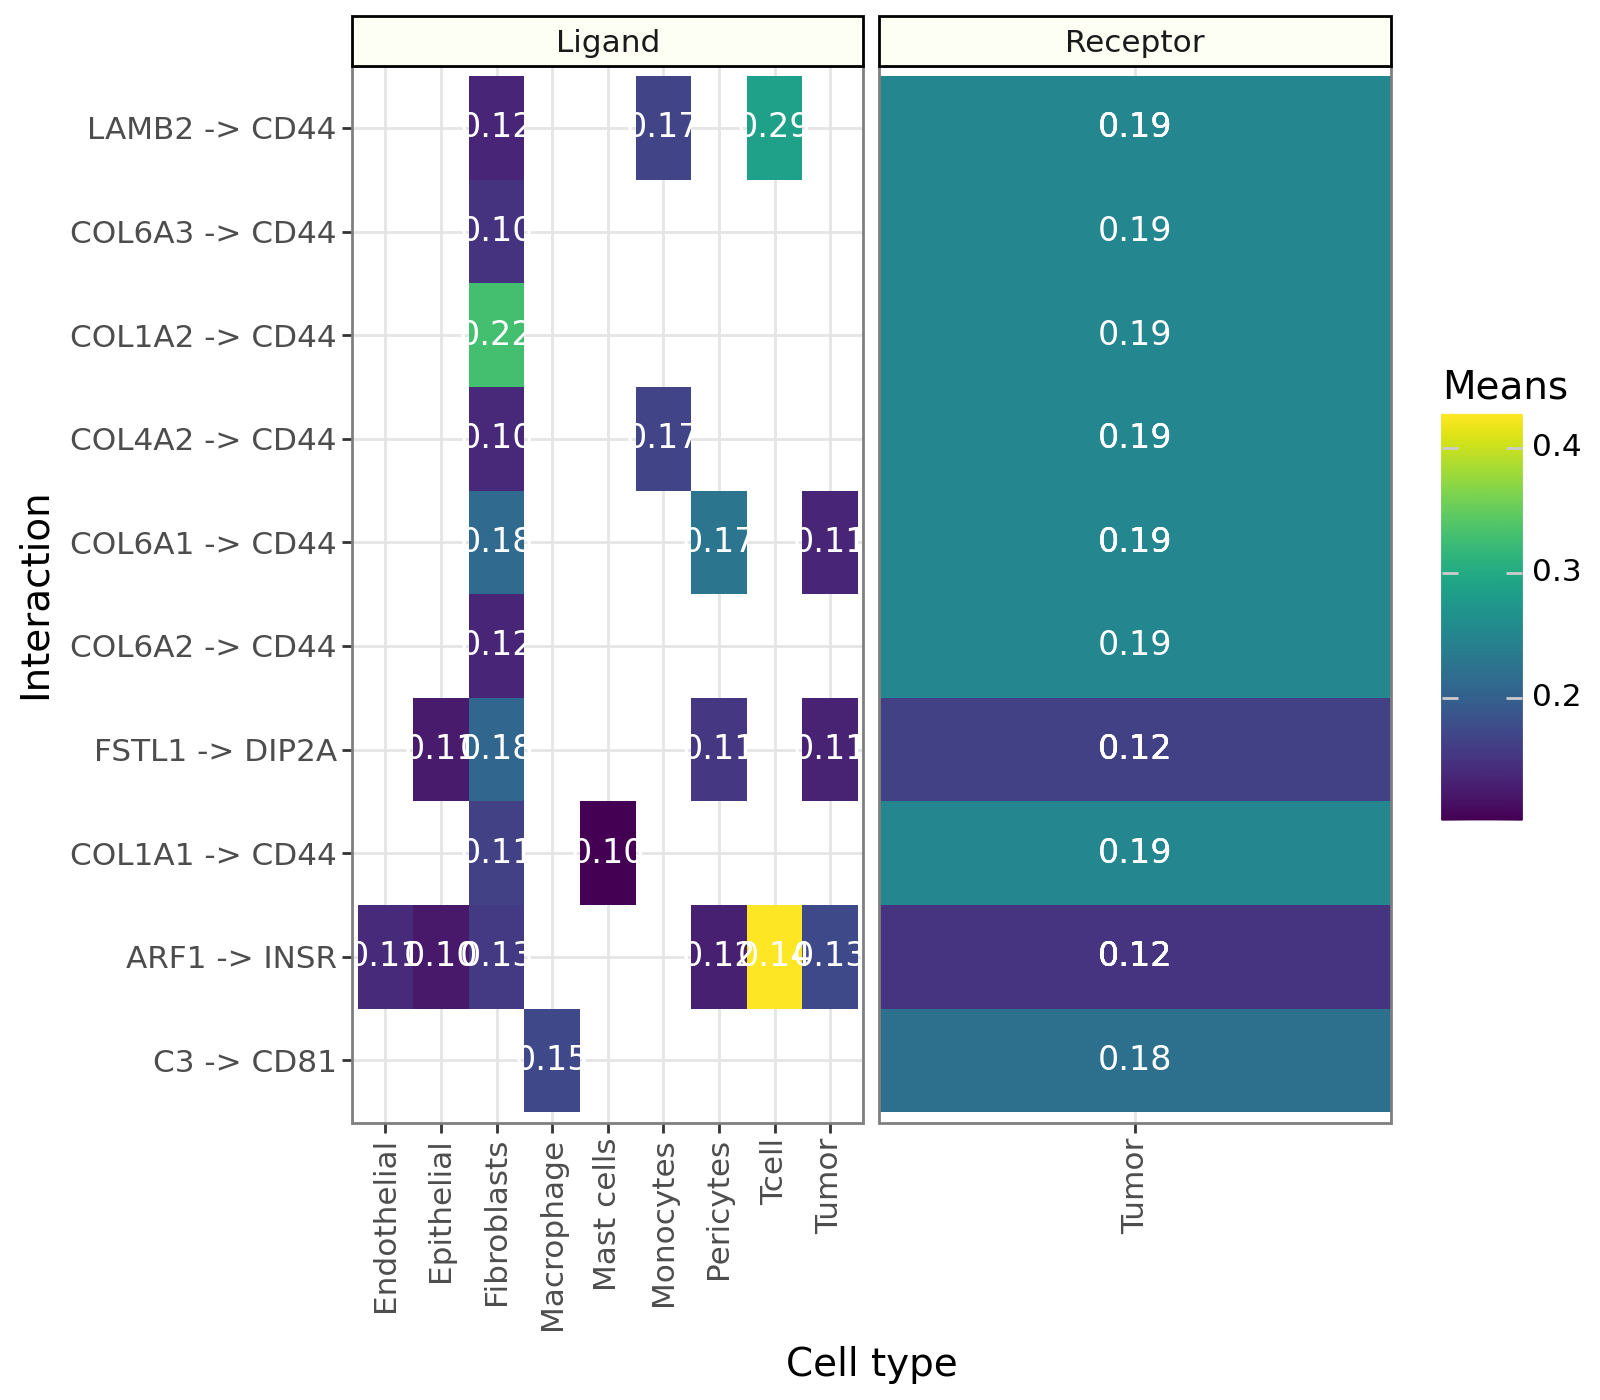

In [185]:
for pattern in pattern_adatas.keys():
    pattern_adata = pattern_adatas[pattern]
    fig = li.pl.tileplot(adata = pattern_adata,
                         fill='means',
                         label='props',
                         label_fun=lambda x: f'{x:.2f}',
                         top_n=10,
                         orderby='cellphone_pvals',
                         orderby_ascending=True,
                         source_labels=pattern_adata.uns['cpdb_res']['source'].unique(),
                         target_labels=['Tumor'],
                         uns_key='cpdb_res', # NOTE: default is 'liana_res'
                         source_title='Ligand',
                         target_title='Receptor',
                         figure_size=(8, 7)
                         )
    fig.show()


### Tumor-originating interactions in selected microarchitectures


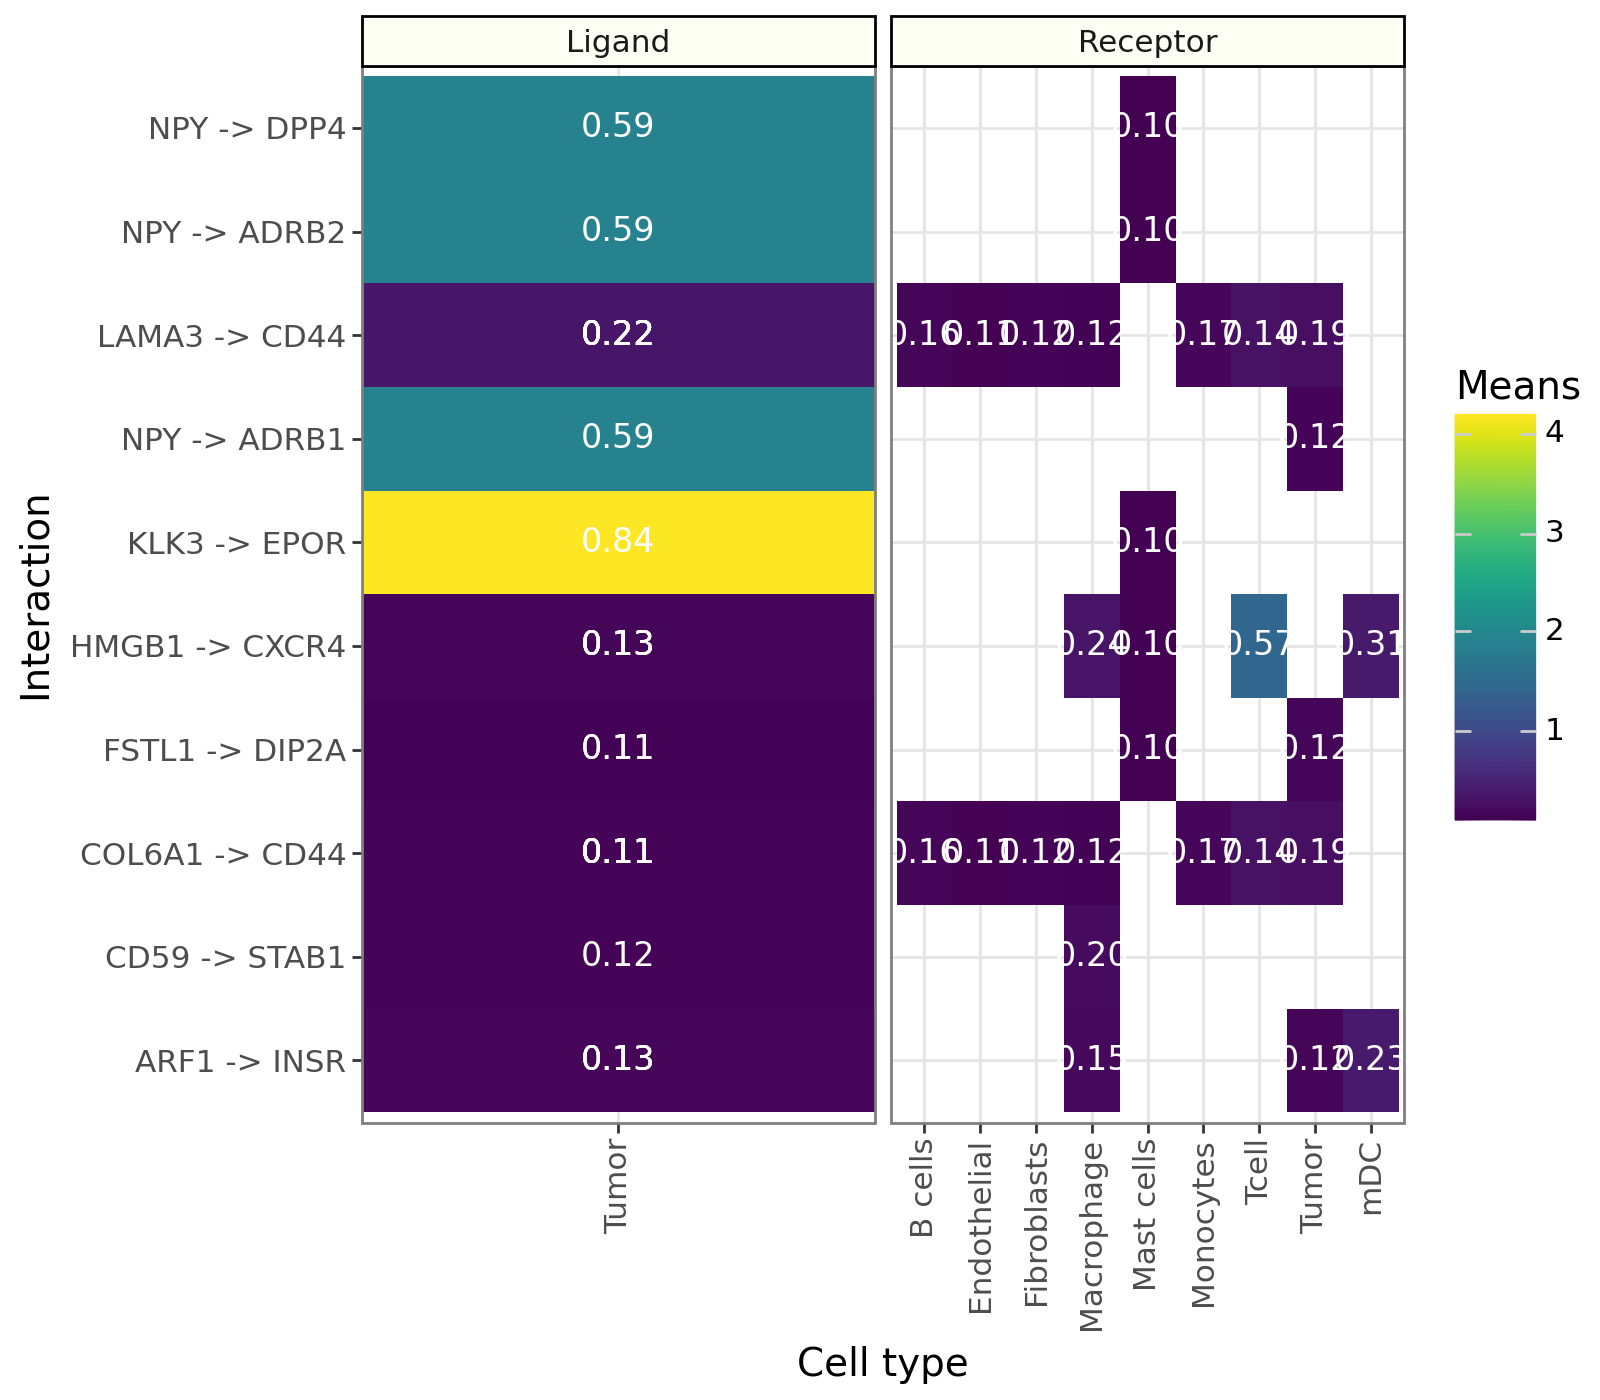

In [187]:
pattern_adata = pattern_adatas['pattern_4']
fig = li.pl.tileplot(adata = pattern_adata,
                     fill='means',
                     label='props',
                     label_fun=lambda x: f'{x:.2f}',
                     top_n=10,
                     orderby='cellphone_pvals',
                     orderby_ascending=True,
                     target_labels=pattern_adata.uns['cpdb_res']['source'].unique(),
                     source_labels=['Tumor'],
                     uns_key='cpdb_res', # NOTE: default is 'liana_res'
                     source_title='Ligand',
                     target_title='Receptor',
                     figure_size=(8, 7)
                     )
fig.show()


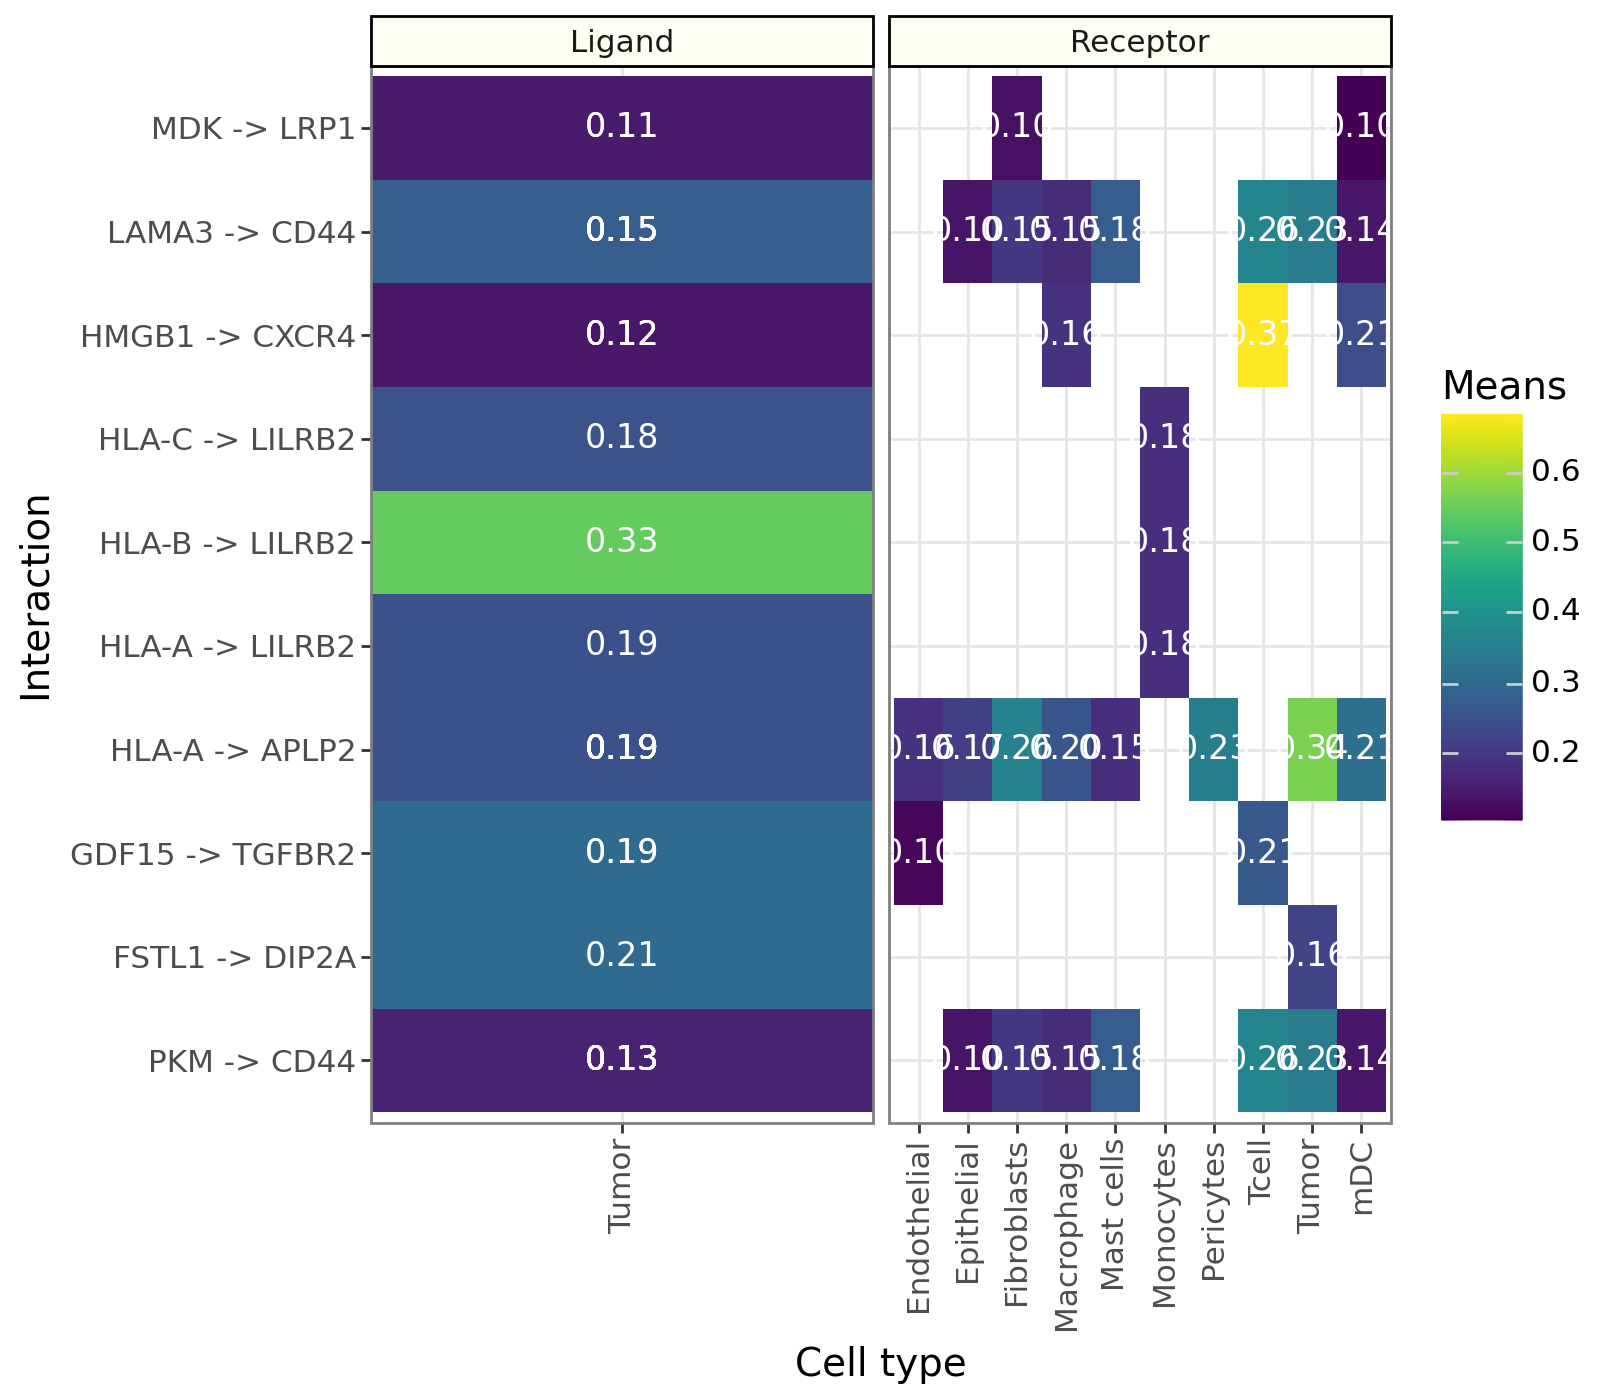

In [188]:
pattern_adata = pattern_adatas['pattern_0']
fig = li.pl.tileplot(adata = pattern_adata,
                     fill='means',
                     label='props',
                     label_fun=lambda x: f'{x:.2f}',
                     top_n=10,
                     orderby='cellphone_pvals',
                     orderby_ascending=True,
                     target_labels=pattern_adata.uns['cpdb_res']['source'].unique(),
                     source_labels=['Tumor'],
                     uns_key='cpdb_res', # NOTE: default is 'liana_res'
                     source_title='Ligand',
                     target_title='Receptor',
                     figure_size=(8, 7)
                     )
fig.show()


### Consensus ligand-receptor ranking and result export

In [189]:
def analyze_pattern_programs_agg_rank(adata, results):
    """
    Aggregate ligand-receptor rankings within each microarchitecture
    """
    import pandas as pd
    import numpy as np
    import anndata as ad
    
    niche_graphs = results['niche_graphs']
    clusters = results['clusters']
    n_patterns = len(np.unique(clusters))
    adatas = {}
    def get_neighbors(pattern_indices):
        """Get expression profiles of neighbors of specific cell type from given niches"""
        neighbors = []
        for idx in pattern_indices:
            niche = niche_graphs[idx]
            cell_indices = niche['neighbors'].index
            neighbors.extend(cell_indices)
        return adata[np.unique(neighbors)]
        
    for pattern in range(n_patterns):
        print(f"\nAnalyzing pattern {pattern}")
        degs_pattern = []
        
        pattern_indices = np.where(clusters == pattern)[0]
        other_indices = np.where(clusters != pattern)[0]
        
        pattern_adata = get_neighbors(pattern_indices)
        
        if len(pattern_adata) < 3:
            print(f"Skipping pattern {pattern}: insufficient cells")
            continue
        
        li.mt.rank_aggregate(
            pattern_adata,
            groupby='cell1',
            # NOTE by default the resource uses HUMAN gene symbols
            resource_name='consensus',
            expr_prop=0.1,
            verbose=True, key_added='cpdb_res')
        adatas[f"pattern_{pattern}"] = pattern_adata
        
    # patterns_adata = ad.concat(adatas, label='niche_pattern')   
    return adatas

In [190]:
agg_rank_adatas = analyze_pattern_programs_agg_rank(adata, results)


Analyzing pattern 0


Generating ligand-receptor stats for 16652 samples and 1378 features
Assuming that counts were `natural` log-normalized!


Running CellPhoneDB


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:02<00:00, 359.59it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


...

Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR



Analyzing pattern 4
Generating ligand-receptor stats for 2486 samples and 1183 features
Assuming that counts were `natural` log-normalized!


Running CellPhoneDB


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 714.96it/s]


Running Connectome
Running log2FC
Running NATMI
Running SingleCellSignalR


In [273]:
aggregate_output = RESULTS_ROOT / "lr-analyses-aggregate"
aggregate_output.mkdir(parents=True, exist_ok=True)

for pattern, pattern_adata in agg_rank_adatas.items():
    fig = li.pl.dotplot(
        adata=pattern_adata,
        colour="magnitude_rank",
        size="specificity_rank",
        inverse_size=True,
        inverse_colour=True,
        source_labels=pattern_adata.uns["cpdb_res"]["source"].unique(),
        target_labels=["Tumor"],
        top_n=15,
        orderby="magnitude_rank",
        uns_key="cpdb_res",
        orderby_ascending=True,
        figure_size=(20, 7),
    )
    fig.save(
        f"pattern_{pattern}_tumor_target_aggregate_lr_top15.pdf",
        path=aggregate_output,
    )


In [271]:
for pattern, pattern_adata in pattern_adatas.items():
    fig = li.pl.tileplot(
        adata=pattern_adata,
        fill="means",
        label="props",
        label_fun=lambda value: f"{value:.2f}",
        top_n=15,
        orderby="cellphone_pvals",
        orderby_ascending=True,
        source_labels=["Tumor"],
        target_labels=pattern_adata.uns["cpdb_res"]["source"].unique(),
        uns_key="cpdb_res",
        source_title="Ligand",
        target_title="Receptor",
        figure_size=(8, 7),
    )
    fig.data.to_csv(
        RESULTS_ROOT / f"pattern_{pattern}_tumor_source_cpdb_lr_top15.csv",
        index=False,
    )


In [232]:
for pattern in pattern_adatas:
    pattern_adatas[pattern].uns["cpdb_res"].to_csv(
        RESULTS_ROOT / f"niche_{pattern}_cellphonedb.csv",
        index=False,
    )
    agg_rank_adatas[pattern].uns["cpdb_res"].to_csv(
        RESULTS_ROOT / f"niche_{pattern}_multi_agg.csv",
        index=False,
    )
